In [1]:
import pandas as pd
import numpy as np
import random
from datetime import datetime, timedelta

np.random.seed(42)
random.seed(42)

In [2]:
n_users = 400
n_gpts = 25
n_days = 60

users = [f"user_{i}" for i in range(n_users)]
gpts = [f"gpt_app_{i}" for i in range(n_gpts)]

departments = ["Engineering", "Finance", "HR", "Sales", "Marketing", "Ops", "Support"]

start_date = datetime(2025, 1, 1)

data = []

for user in users:
    dept = random.choice(departments)
    usage_intensity = np.random.beta(2, 4)  # skewed usage distribution

    for day in range(n_days):
        if np.random.rand() < usage_intensity:
            gpt = random.choice(gpts)

            prompts = np.random.poisson(3) + 1
            tokens = int(np.random.normal(2000, 800))

            # cost per token (enterprise model simulation)
            cost = max(tokens, 100) * 0.00002

            data.append([
                user,
                dept,
                gpt,
                start_date + timedelta(days=day),
                prompts,
                max(tokens, 100),
                round(cost, 4)
            ])

df = pd.DataFrame(data, columns=[
    "user_id",
    "department",
    "gpt_app",
    "date",
    "prompt_count",
    "tokens_used",
    "cost_usd"
])

df.head()

,user_id,department,gpt_app,date,prompt_count,tokens_used,cost_usd
0,user_0,Ops,gpt_app_3,2025-01-01,2,2223,0.0445
1,user_0,Ops,gpt_app_0,2025-01-03,4,2808,0.0562
2,user_0,Ops,gpt_app_23,2025-01-04,4,1189,0.0238
3,user_0,Ops,gpt_app_8,2025-01-05,4,2251,0.0450
4,user_0,Ops,gpt_app_7,2025-01-08,3,1519,0.0304


In [3]:
usage_summary = df.groupby("gpt_app").agg({
    "tokens_used": "sum",
    "cost_usd": "sum",
    "prompt_count": "sum",
    "user_id": "nunique"
}).reset_index()

usage_summary.columns = [
    "gpt_app",
    "total_tokens",
    "total_cost",
    "total_prompts",
    "unique_users"
]

usage_summary.sort_values("total_cost", ascending=False).head()

,gpt_app,total_tokens,total_cost,total_prompts,unique_users
9,gpt_app_17,742048,14.8403,1471,228
14,gpt_app_21,719870,14.3977,1469,232
13,gpt_app_20,719071,14.3818,1409,210
19,gpt_app_4,702196,14.0445,1406,224
17,gpt_app_24,695516,13.9101,1415,219


In [4]:
dept_cost = df.groupby("department").agg({
    "cost_usd": "sum",
    "tokens_used": "sum",
    "user_id": "nunique"
}).reset_index()

dept_cost["cost_per_user"] = dept_cost["cost_usd"] / dept_cost["user_id"]
dept_cost["cost_per_token"] = dept_cost["cost_usd"] / dept_cost["tokens_used"]

dept_cost.sort_values("cost_usd", ascending=False)

,department,cost_usd,tokens_used,user_id,cost_per_user,cost_per_token
1,Finance,53.8255,2691343,67,0.803366,0.00002
3,Marketing,53.7338,2686653,61,0.880882,0.00002
6,Support,52.0498,2602463,60,0.867497,0.00002
5,Sales,49.7855,2489321,57,0.873430,0.00002
0,Engineering,42.9577,2147856,48,0.894952,0.00002
4,Ops,40.5470,2027377,53,0.765038,0.00002
2,HR,39.3256,1966216,53,0.741992,0.00002


In [5]:
from sklearn.preprocessing import MinMaxScaler

scaler = MinMaxScaler()

metrics = usage_summary.copy()

metrics_scaled = metrics.copy()
metrics_scaled[["total_tokens","total_cost","total_prompts","unique_users"]] = scaler.fit_transform(
    metrics_scaled[["total_tokens","total_cost","total_prompts","unique_users"]]
)

metrics_scaled["efficiency_score"] = (
    0.25 * metrics_scaled["total_prompts"] +
    0.25 * metrics_scaled["unique_users"] -
    0.30 * metrics_scaled["total_tokens"] -
    0.20 * metrics_scaled["total_cost"]
)

metrics_scaled.sort_values("efficiency_score", ascending=False).head()

,gpt_app,total_tokens,total_cost,total_prompts,unique_users,efficiency_score
14,gpt_app_21,0.888521,0.888732,0.994065,1.000000,0.054214
1,gpt_app_1,0.437392,0.437403,0.516320,0.444444,0.021493
16,gpt_app_23,0.678280,0.678465,0.727003,0.711111,0.020352
19,gpt_app_4,0.799681,0.799940,0.807122,0.822222,0.007444
17,gpt_app_24,0.766104,0.766152,0.833828,0.711111,0.003173


In [6]:
waste_analysis = usage_summary.copy()

waste_analysis["cost_per_prompt"] = waste_analysis["total_cost"] / waste_analysis["total_prompts"]

waste_analysis.sort_values("cost_per_prompt", ascending=False).head()

,gpt_app,total_tokens,total_cost,total_prompts,unique_users,cost_per_prompt
11,gpt_app_19,694430,13.8888,1307,206,0.010626
10,gpt_app_18,676061,13.5213,1286,206,0.010514
2,gpt_app_10,672976,13.4595,1285,212,0.010474
15,gpt_app_22,679202,13.5837,1309,217,0.010377
18,gpt_app_3,654185,13.0829,1262,218,0.010367


In [7]:
reuse_analysis = df.groupby("gpt_app").agg({
    "user_id": "nunique",
    "prompt_count": "sum"
}).reset_index()

reuse_analysis["reuse_ratio"] = reuse_analysis["prompt_count"] / reuse_analysis["user_id"]

reuse_analysis.sort_values("reuse_ratio", ascending=False).head()

,gpt_app,user_id,prompt_count,reuse_ratio
13,gpt_app_20,210,1409,6.709524
7,gpt_app_15,199,1334,6.703518
4,gpt_app_12,211,1394,6.606635
22,gpt_app_7,201,1307,6.502488
17,gpt_app_24,219,1415,6.461187


In [8]:
df.to_csv("gpt_usage_logs.csv", index=False)
usage_summary.to_csv("gpt_usage_summary.csv", index=False)
dept_cost.to_csv("department_cost_analysis.csv", index=False)
metrics_scaled.to_csv("gpt_efficiency_scores.csv", index=False)

In [9]:
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_style("whitegrid")

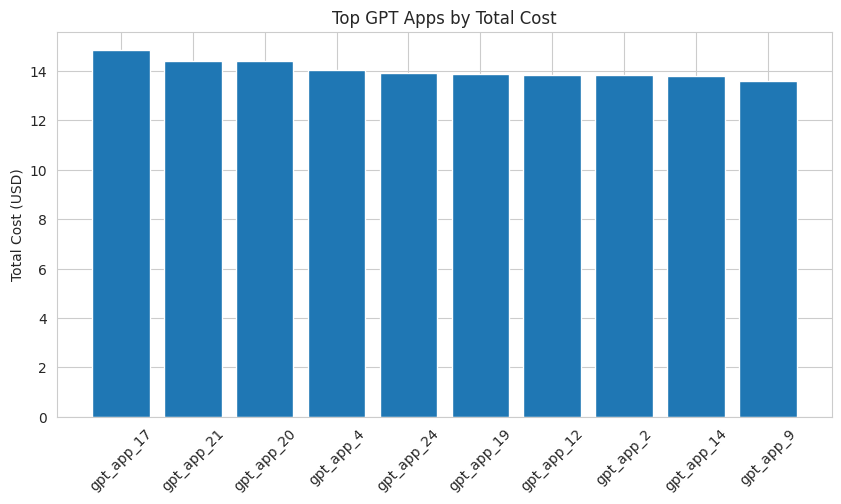

In [10]:
top_gpts = usage_summary.sort_values("total_cost", ascending=False).head(10)

plt.figure(figsize=(10,5))
plt.bar(top_gpts["gpt_app"], top_gpts["total_cost"])
plt.title("Top GPT Apps by Total Cost")
plt.xticks(rotation=45)
plt.ylabel("Total Cost (USD)")
plt.show()

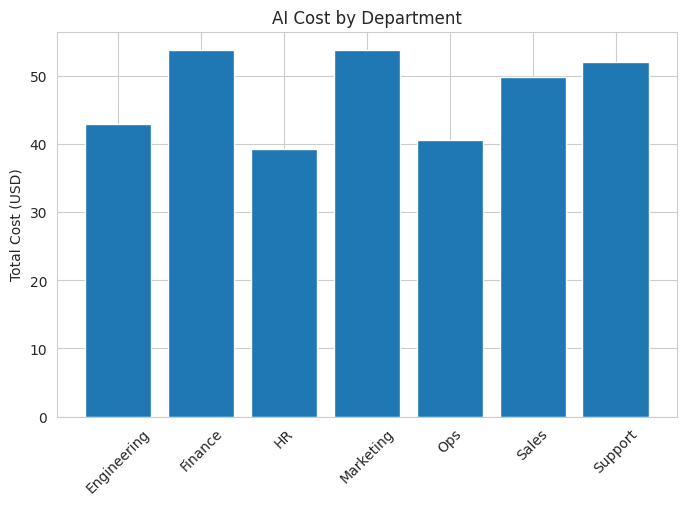

In [11]:
plt.figure(figsize=(8,5))
plt.bar(dept_cost["department"], dept_cost["cost_usd"])
plt.title("AI Cost by Department")
plt.xticks(rotation=45)
plt.ylabel("Total Cost (USD)")
plt.show()

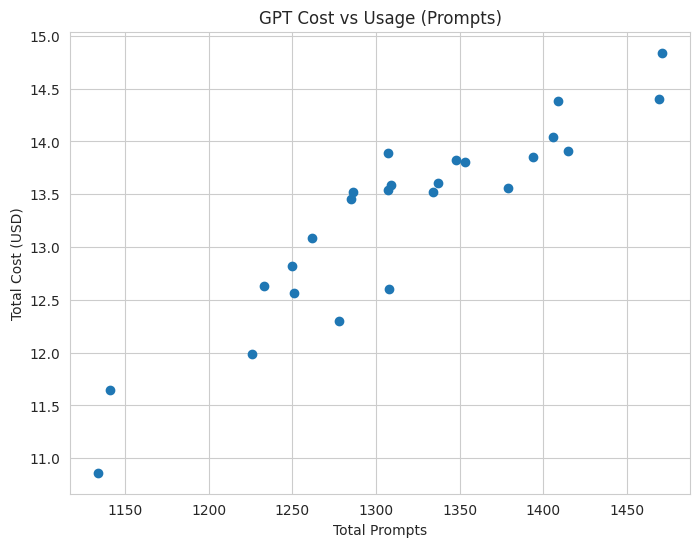

In [12]:
plt.figure(figsize=(8,6))
plt.scatter(
    usage_summary["total_prompts"],
    usage_summary["total_cost"]
)

plt.title("GPT Cost vs Usage (Prompts)")
plt.xlabel("Total Prompts")
plt.ylabel("Total Cost (USD)")
plt.show()

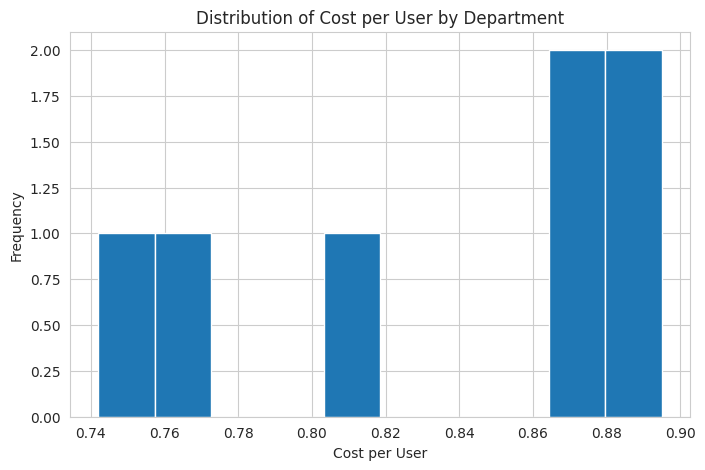

In [13]:
plt.figure(figsize=(8,5))
plt.hist(dept_cost["cost_per_user"], bins=10)
plt.title("Distribution of Cost per User by Department")
plt.xlabel("Cost per User")
plt.ylabel("Frequency")
plt.show()

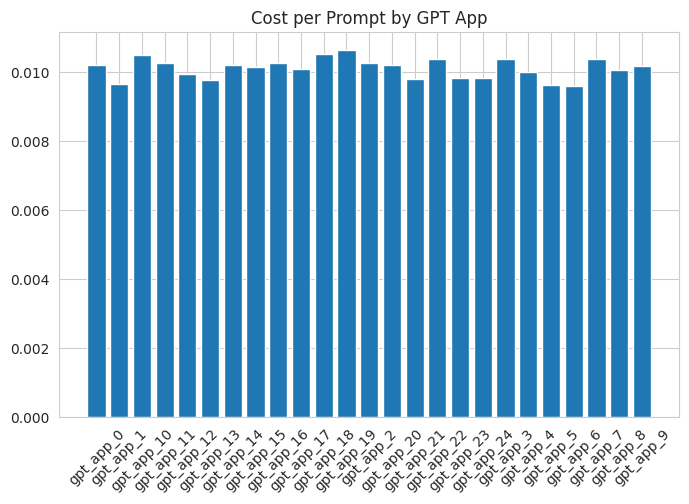

In [14]:
usage_summary["cost_per_prompt"] = usage_summary["total_cost"] / usage_summary["total_prompts"]

plt.figure(figsize=(8,5))
plt.bar(usage_summary["gpt_app"], usage_summary["cost_per_prompt"])
plt.title("Cost per Prompt by GPT App")
plt.xticks(rotation=45)
plt.show()